In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

# Part 1: Data Preparation and Exploration

In [2]:
df = pd.read_excel("CST-570-RS-WAFn-UseC-Telco-Customer-Churn.xlsx")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Missing data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- No missing data in any of our columns

## Changing Data for Exploratory purposes

In [4]:
for col in df.columns:
    print(df[col].value_counts())
    print("===============================")

customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    15

### Senior citizen

In [5]:
df_eda = df.copy()

In [6]:
df_eda['SeniorCitizen'] = df_eda['SeniorCitizen'].map({
    1: 'Senior Citizen',
    0: 'Not Senior Citizen'
})

df_eda["SeniorCitizen"][:5]

0    Not Senior Citizen
1    Not Senior Citizen
2    Not Senior Citizen
3    Not Senior Citizen
4    Not Senior Citizen
Name: SeniorCitizen, dtype: object

### Churn

In [7]:
df_eda['Churn'] = df_eda['Churn'].astype('category')
df_eda['Churn'][:5]

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: category
Categories (2, object): ['No', 'Yes']

### Binary Features

In [8]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']

for col in binary_cols:
    df_eda[col] = df_eda[col].astype('category')
    print(df_eda[col][:5])


0    Yes
1     No
2     No
3     No
4     No
Name: Partner, dtype: category
Categories (2, object): ['No', 'Yes']
0    No
1    No
2    No
3    No
4    No
Name: Dependents, dtype: category
Categories (2, object): ['No', 'Yes']
0     No
1    Yes
2    Yes
3     No
4    Yes
Name: PhoneService, dtype: category
Categories (2, object): ['No', 'Yes']
0    Yes
1     No
2    Yes
3     No
4    Yes
Name: PaperlessBilling, dtype: category
Categories (2, object): ['No', 'Yes']


### TotalCharges

- These are text and we need to change them into numeric

In [9]:
df_eda["TotalCharges"] = (df_eda["TotalCharges"].replace(" ", ).astype(float))
df_eda["TotalCharges"][:10]

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
5     820.50
6    1949.40
7     301.90
8    3046.05
9    3487.95
Name: TotalCharges, dtype: float64

### Ordered Category Contract

In [10]:
contract_order = ['Month-to-month','One year','Two year']
df_eda["Contract"] =  pd.Categorical(df_eda["Contract"], 
               categories=contract_order,
              ordered=True)
df_eda["Contract"]

0       Month-to-month
1             One year
2       Month-to-month
3             One year
4       Month-to-month
             ...      
7038          One year
7039          One year
7040    Month-to-month
7041    Month-to-month
7042          Two year
Name: Contract, Length: 7043, dtype: category
Categories (3, object): ['Month-to-month' < 'One year' < 'Two year']

### Creating internet column

In [11]:
df_eda["HasInternet"] = df_eda["InternetService"] != 'No'
df_eda["HasInternet"].value_counts()

HasInternet
True     5517
False    1526
Name: count, dtype: int64

In [12]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   object  
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 n

## How the Data was Prepared for analysis

- I have only change some variables to make analysis easier to plot and understand. I have also created another column in order to group the customers with those who have internet and those who do not. We have also change the binary columns into categories in order for pandas to not treat these as numeric values. We can correctly count groups and make bar visualizations. 

## Exploratory analysis Bivariate

In [13]:
df_eda.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2285.169963
std,24.559481,30.090047,2267.544511
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.675000
50%,29.000000,70.350000,1398.250000
75%,55.000000,89.850000,3803.050000
max,72.000000,118.750000,8684.800000


### Churn

In [14]:
df_eda["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Churn')

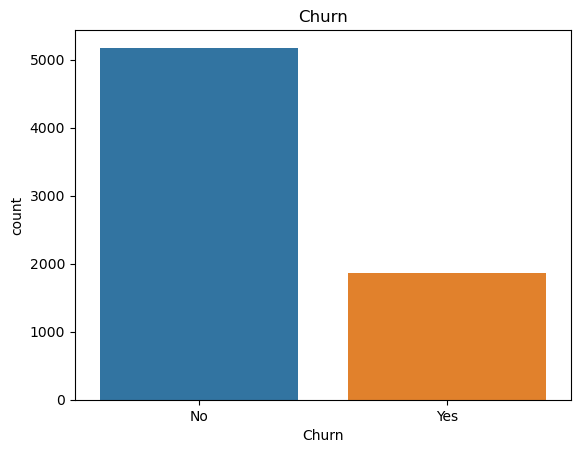

In [15]:
sns.countplot(data=df_eda, x="Churn")
plt.title("Churn")

- We can clearly see an imbalance in churn with more customers who do not churn, this can be a problem later when we build our model. We have to consider other evaluation metrics later rather than just relying on accuracy

### Churn vs Tenure

Text(0.5, 1.0, 'Tenure of Customers vs Churn')

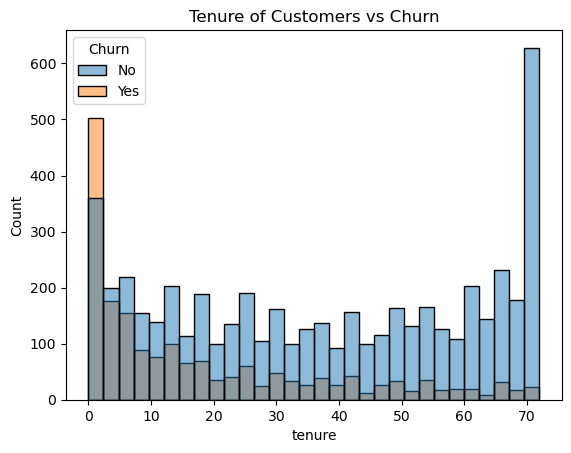

In [16]:
sns.histplot(data=df_eda, x="tenure", hue="Churn", bins=30)
plt.title("Tenure of Customers vs Churn")

- We can see here that we have the highest churn rate in the early months of tenure. Churn is very concentrated at low tenure, customers who have been with the company for a short time tend to churn more than those who have stayed with the company longer
<br><br>
- Judging from the graph this indicated that tenure is going to be a strong predictor against churn. This means that tenure will likely have negative coefficient in our model since the higher the tenure the lower the probability of churn

### Monthly charges for churn vs not churn

Text(0.5, 1.0, 'Monthly Charges of Customers (Churned/Not Churned)')

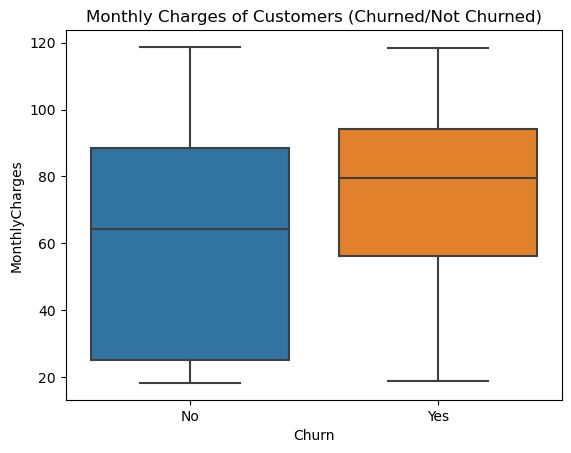

In [17]:
sns.boxplot(data=df_eda, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges of Customers (Churned/Not Churned)")

- On average those who did churn ended up paying more monthly than those who did not churn
<br><br>
- Both of the groups show wide variation in the amount they pay monthly, but more of those who did not churn pay a little over 20 to about 86, those did churn most paid from 57 to about 90, this indicates that lower paying customers are less likely to leave. One thing that comes to mind could be that those stay might only be using certain services which cost less than those who have churned, or they got a really good deal on promotion for a service.
<br><br>
- Both groups have similar maximum values so high paying customer exist in both groups but more so in the customers who have churned.
<br><br>
- This indicates that monthly charges will most likely have a positive coefficient in our model, as monthly charges goes up churn probability goes up.

### Total Charges

Text(0.5, 1.0, 'Total Charges of Customers (Churned not Churned)')

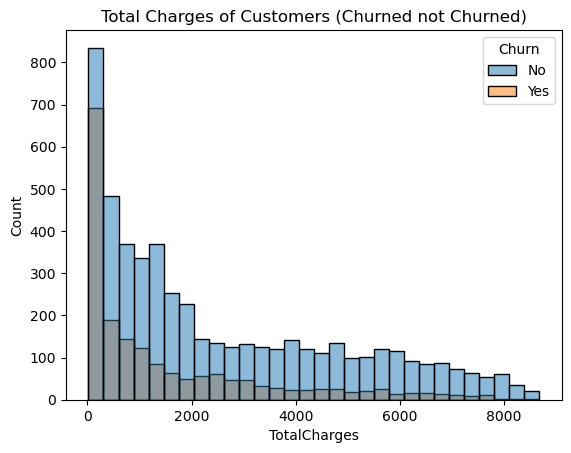

In [18]:
sns.histplot(data=df_eda, x="TotalCharges", hue="Churn", bins=30)
plt.title("Total Charges of Customers (Churned not Churned)")

- Most churned customers have very low total charges which makes sense since our previous graph graph where customers who pay more monthly tend to churn and leave the company sooner. <br><br>
- Many customers choose to leave early, before accumulating high total charges which make sense because the longer someone stays the lower the chance of churn. The same pattern appears for high total charges and low total charges low charge - high churn high total charge - low churn <br><br>
- total charges will have a negative coefficient in our model, the higher the total charge the lower the churn probability

### Churn by contract type

Text(0.5, 1.0, 'Churn rate by Contract')

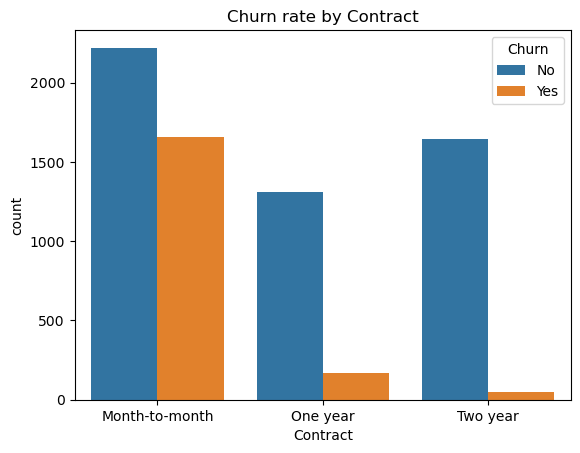

In [19]:
sns.countplot(data=df_eda, x="Contract", hue="Churn",)
plt.title("Churn rate by Contract")

- We can see that those who have one and two year contracts tend to stay with the company. It is interesting to see that more customers on the month to month side end up staying with the company than those who churn.<br><br>

- This is most likely going to be a strong predictor because from the graph we can see that the longer the contract the lower the probability of churn so this will have a negative coefficient in our model. <br><br>

- This indicates that customers experience the service for longer tend to like the service, and stay. The problem we face here is how do we get new customers to stay for at least one year. 

### Demographic vs Churn

Text(0.5, 1.0, 'Demographic Churn Rate')

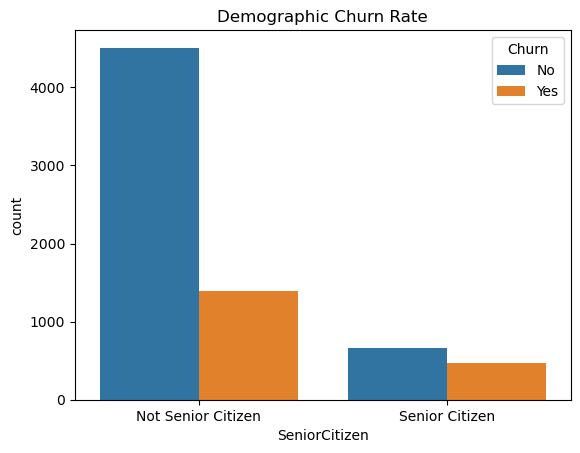

In [20]:
sns.countplot(data=df_eda, x="SeniorCitizen", hue="Churn")
plt.title("Demographic Churn Rate")

In [21]:
df_eda["SeniorCitizen"].value_counts()

SeniorCitizen
Not Senior Citizen    5901
Senior Citizen        1142
Name: count, dtype: int64

- Here we can see that Seniors churn at a higher rate than those who are not, but this might also be due to the fact that we have more people who are not senior citizens than those who are. We might need more data points before we jump to conclusions.

### Partner and Dependents vs Churn

Text(0.5, 1.0, 'Churn rate and Relationship Status')

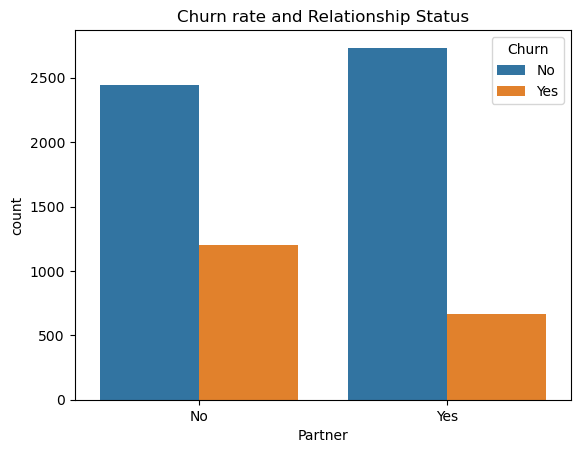

In [22]:
sns.countplot(data=df_eda, x="Partner", hue="Churn")
plt.title("Churn rate and Relationship Status")

- The churn rate of those who have a partner to those is similar but seems to be higher than for those who do not have a partner. It seems to be that having a partner reduces the churn rate. This might be due to another person requiring the service or split bills.

Text(0.5, 1.0, 'Dependents Churn Rate')

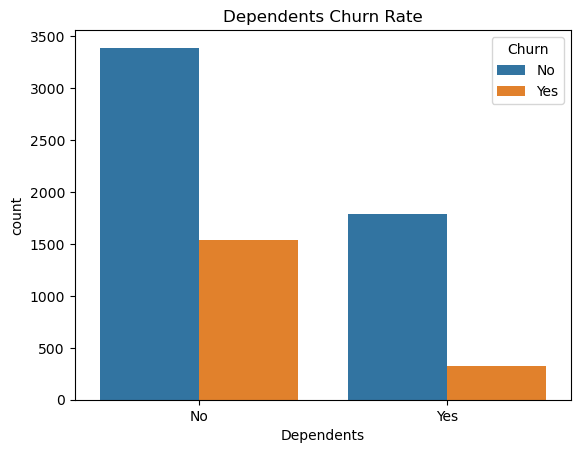

In [23]:
sns.countplot(data=df_eda, x="Dependents", hue="Churn")
plt.title("Dependents Churn Rate")

- We can see that having dependents leads to a lower churn rate. This could also be due to having more people needing the service or maybe getting a better deal on services making it "worth" the money

### Internet services Type

Text(0.5, 1.0, 'Internet Service Type vs Churn Rate')

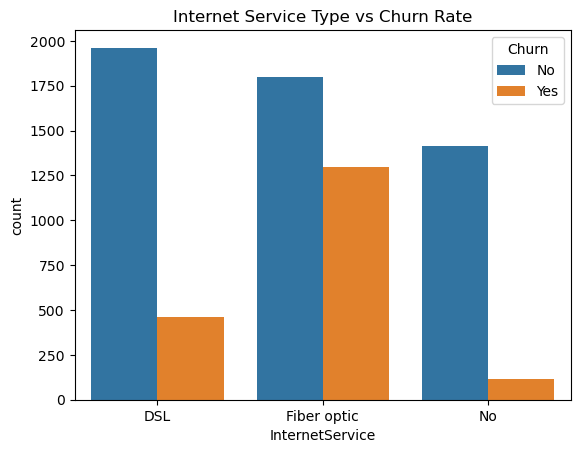

In [24]:
sns.countplot(data=df_eda, x="InternetService", hue="Churn")
plt.title("Internet Service Type vs Churn Rate")

- Having a Fiber Optic service leads to a higher churn rate, this might be because the service might be too expensive. Those who do not have internet and DSL service have a low churn rate. 

### Payment method

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

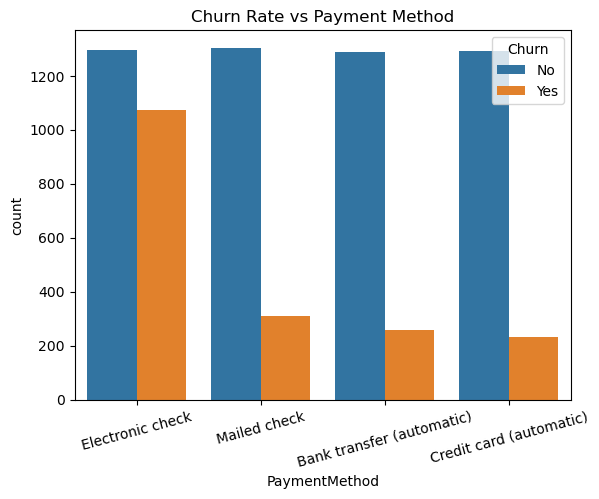

In [25]:
sns.countplot(data=df_eda, x="PaymentMethod", hue="Churn")
plt.title("Churn Rate vs Payment Method")
plt.xticks(rotation=15)

- This is interesting we have a very high churn rate for those who pay through electronic check. This is a behavior signal that is related to churn risk. Those who pay through e-check might be experiencing problems with payment and would be a positive coefficient in our model, where the probability of churn increases if the customer is using e-check

### Service Usage

In [26]:
services = [
 'OnlineSecurity','OnlineBackup','DeviceProtection',
 'TechSupport','StreamingTV','StreamingMovies'
]

In [27]:
df_eda["num_services"] = (df_eda[services] == "Yes").sum(axis=1)

Text(0.5, 1.0, 'Churn vs Number of Services')

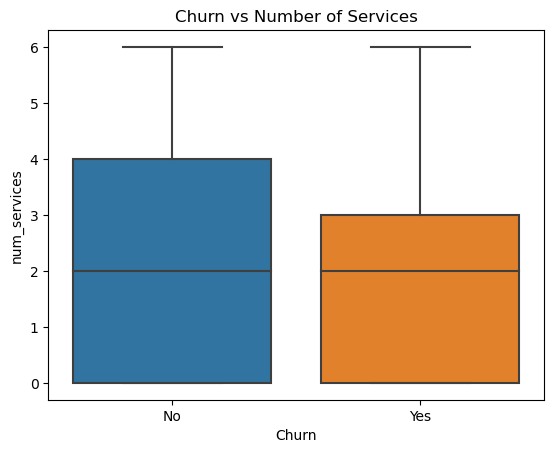

In [28]:
sns.boxplot(data=df_eda, x="Churn", y="num_services")
plt.title('Churn vs Number of Services')

- Here we can see that those who have more services tend to stay longer than those with fewer services. Likely due to the commitment people have to their services and having to find a different provider that includes all the services they need. But the plots are similar

### Money and Tenure

Text(0.5, 1.0, 'Monthly Charges vs Tenure and Churn')

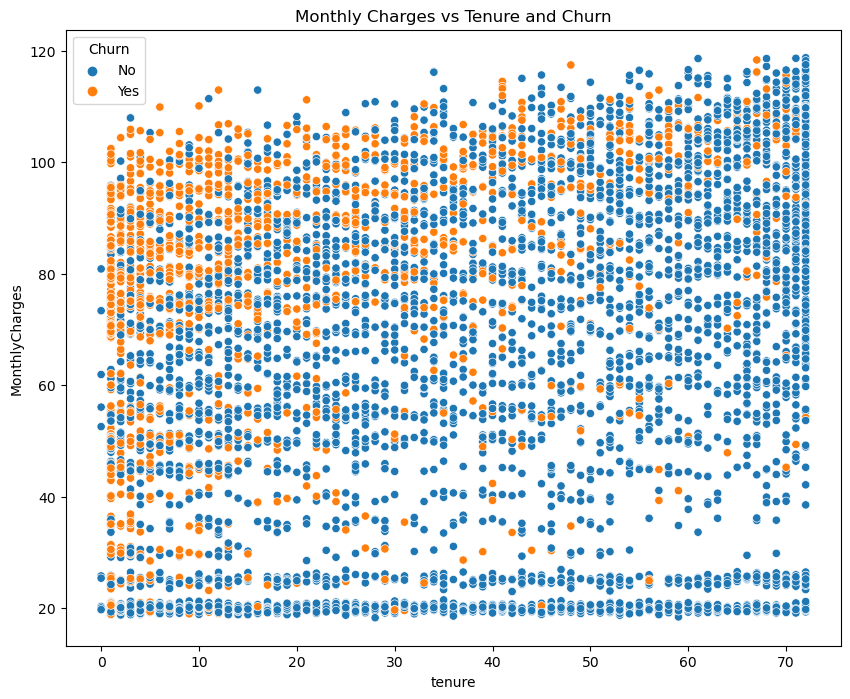

In [29]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_eda, x='tenure', y='MonthlyCharges', hue="Churn")
plt.title("Monthly Charges vs Tenure and Churn")

- Here we can see that majority of those who churn are concentrated from 0-10 months with the company especially those with high monthly payments and low tenure, high paying customers also tend to churn, compared to those who pay less monthly. 

## Summary

- Preliminary exploratory analysis of the Telco customer churn dataset indicates that churn is systematically related to tenure, charges, contract type, payment method, and service usage rather than occurring at random. Customers with short tenure showed the highest churn rates, while long tenure customers were much more likely to remain, suggesting tenure is likely to have a negative relationship with churn in a logistic regression model. Customers who churned tended to have higher MonthlyCharges, indicating that higher costs are associated with increased churn risk. TotalCharges showed an inverse relationship with churn, but this largely reflected its correlation with tenure rather than providing independent predictive value. Month-to-month contracts and electronic check payment methods were associated with substantially higher churn, whereas two-year contracts and automatic payments were linked to greater retention. Additionally, fiber optic customers showed higher churn than DSL or non-internet customers, while customers using more internet services tended to remain longer.

- I used a combination of histograms, boxplots, count plots, and summary statistics was used to support these findings. Histograms were appropriate for examining the distribution of continuous variables such as tenure and TotalCharges and identifying where churn was concentrated. Boxplots effectively compared the distribution of MonthlyCharges across churn groups while minimizing the influence of outliers. Count plots were used for categorical variables like Contract and PaymentMethod because they clearly displayed differences in churn proportions across groups. Together, these tools provided a reliable foundation for selecting predictors and specifying a logistic regression model

# Logistic Regression

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, RocCurveDisplay, accuracy_score
)
from sklearn.linear_model import LogisticRegression

## Objective on Analysis

## Objective of the Analysis

- Our objective is of this analysis is to build and evaluate a multiple logistic regression model and determine whether customers will churn. <br><br>
- We have to identify which characteristics are associated with churn, and how those characteristics affect the odds of people churning. Then assess the model using accuracy calibration, and discrimination.

In [31]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Prepping dataset for Modeling

In [32]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"][:5]

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [33]:
df["TotalCharges"] = (df["TotalCharges"].replace(" ", ).astype(float))

In [34]:
df["TotalCharges"] = (df["TotalCharges"].replace(" ", ).astype(float))
df["TotalCharges"][:5]

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [35]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [36]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

- We have a high imbalance of classes with fewer people who have left the company, so accuracy won't tell us everything we will need to check ROC/AUC curves

## Univariate

In [37]:
y = "Churn"
X = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "tenure", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "PaperlessBilling",
    "PaymentMethod", "MonthlyCharges", "TotalCharges"
]

In [38]:
model_df = df[X + [y]].copy()
model_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [39]:
model_df[X[2:]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2285.169963
std,24.559481,30.090047,2267.544511
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.675000
50%,29.000000,70.350000,1398.250000
75%,55.000000,89.850000,3803.050000
max,72.000000,118.750000,8684.800000


- Here we have the summary of our numeric columns, and we get a nice overview of their statistics. We have high variation in total charges which makes sense since those who have stayed with the company longer have high accumulated charges. Other statistics seam normal at a glance

### Univariate 

#### Histograms

array([[<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >]], dtype=object)

<Figure size 1000x800 with 0 Axes>

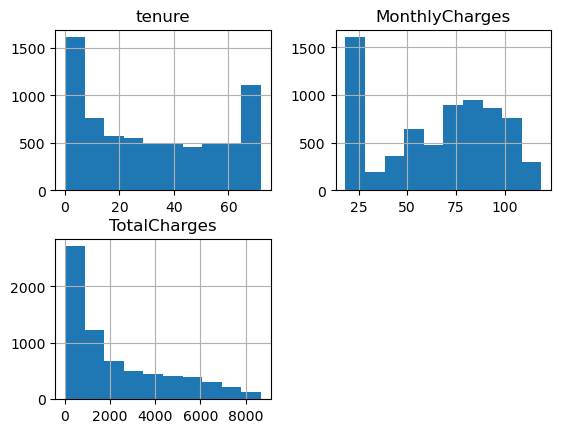

In [40]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(10,8))
model_df[num_cols].hist()

- Tenure is slightly right skewed with more short term customers than long term customers<br><br>
- Monthly charges is roughly symmetric but we do have many customers with roughly 25 monthly charges and most of the concentration between 50-100 <br><br>
- Total Charges is right skewed since customers with high tenure have a accumulated many total charges. 

In [41]:
cat_col = [col for col in X if col not in num_cols]

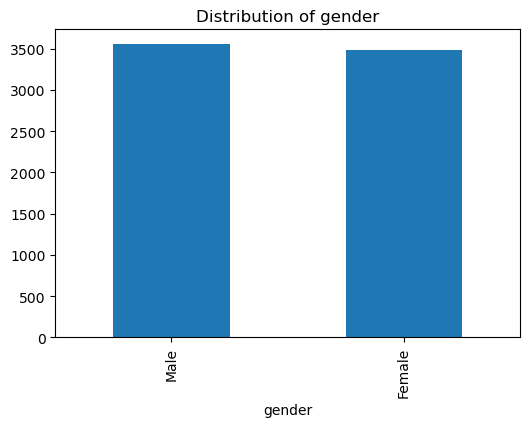

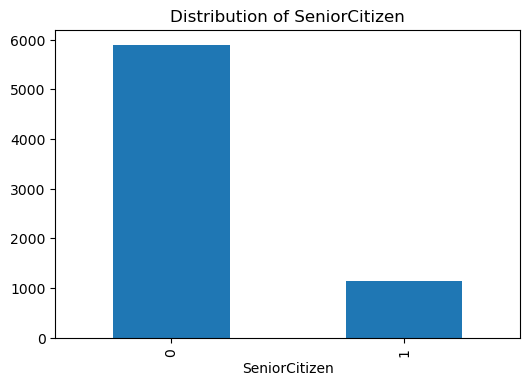

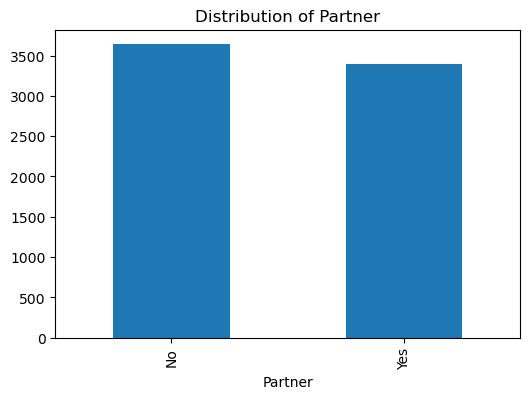

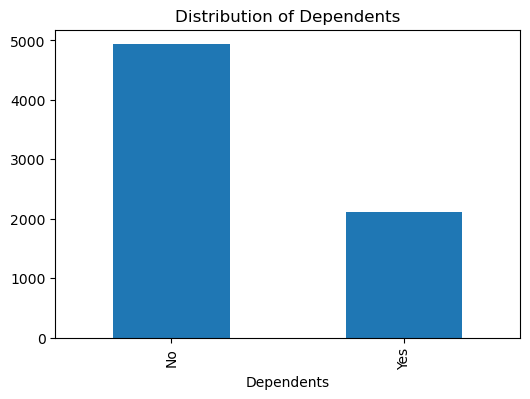

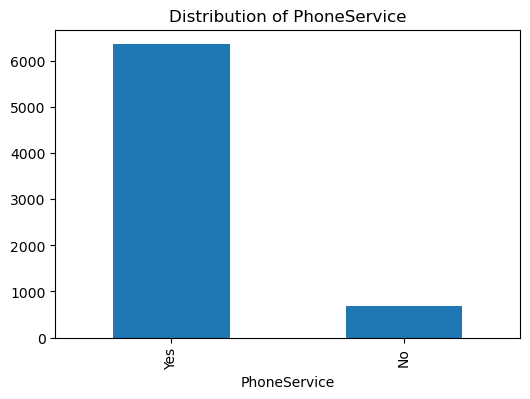

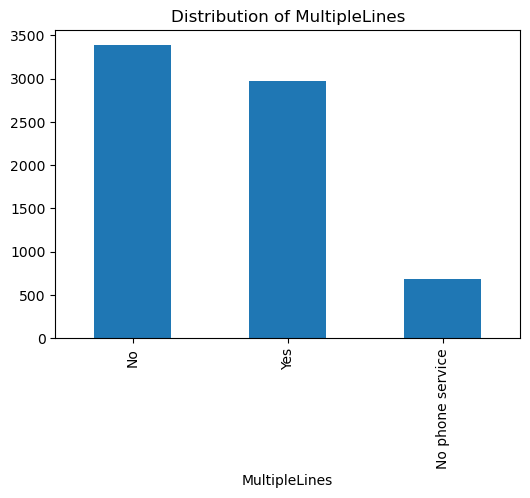

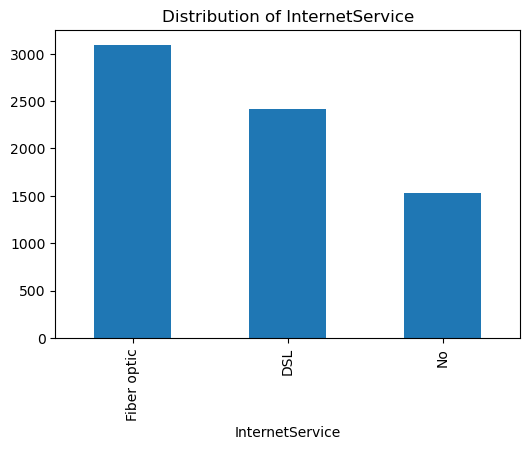

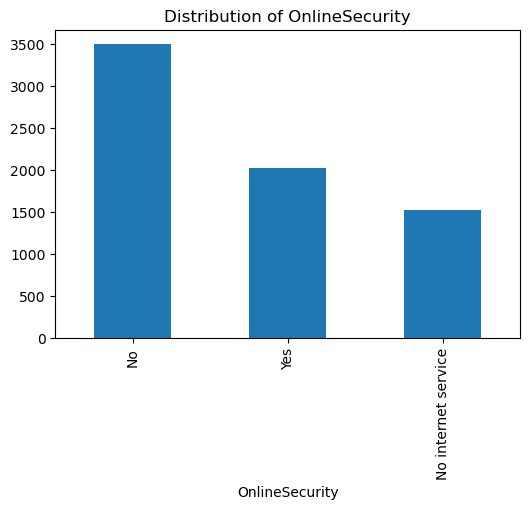

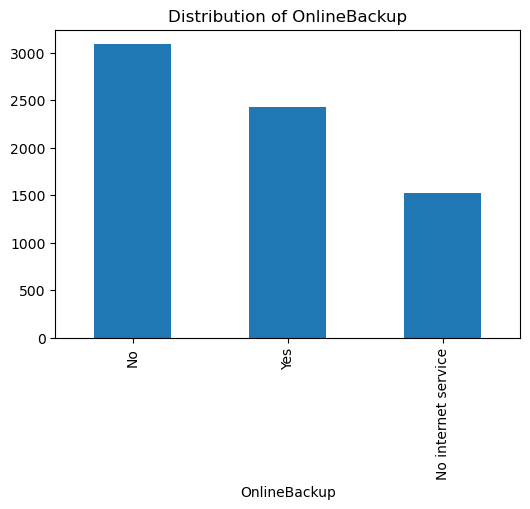

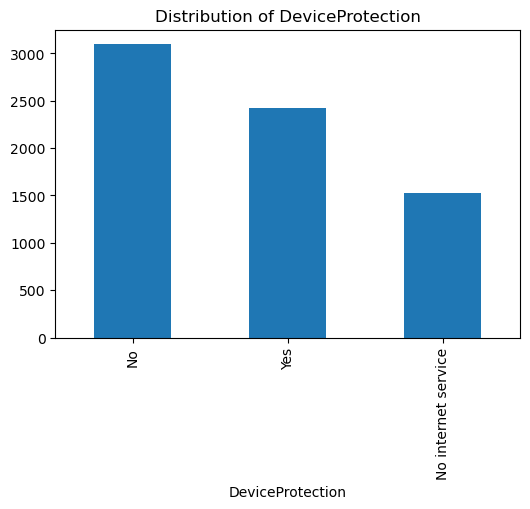

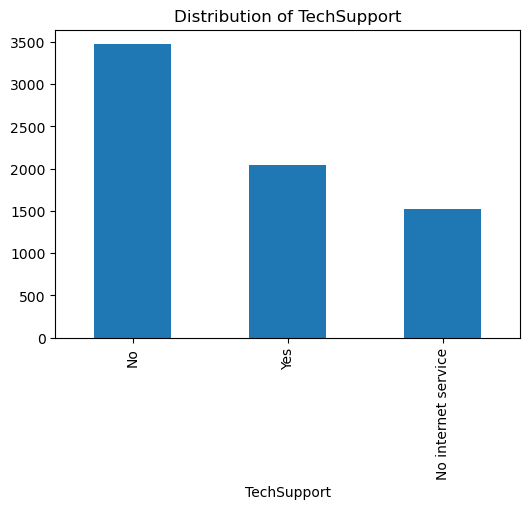

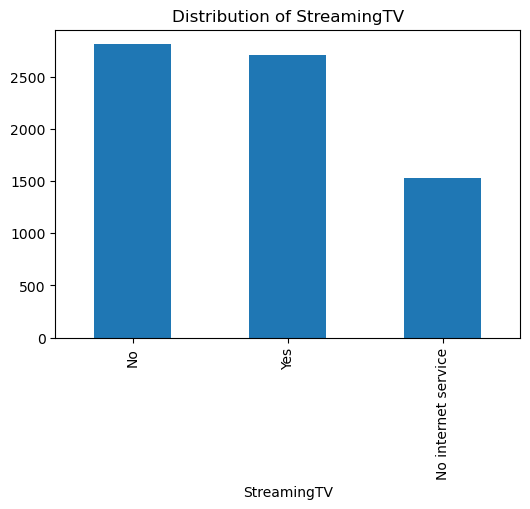

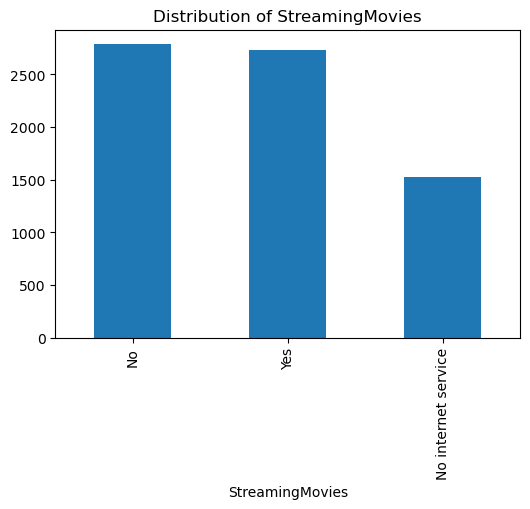

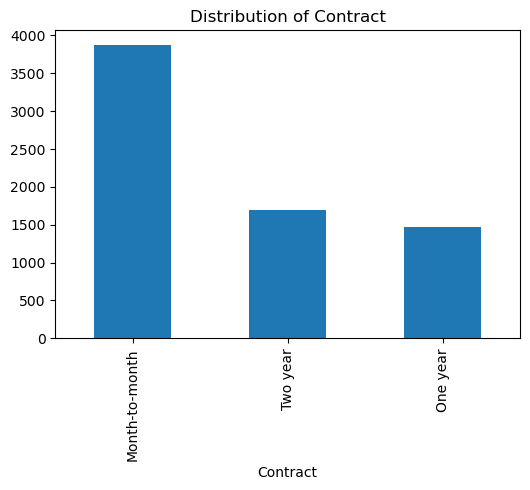

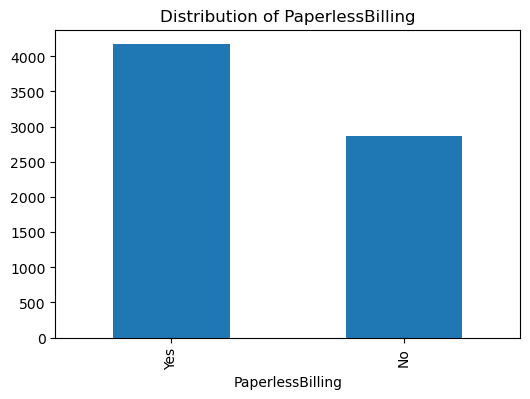

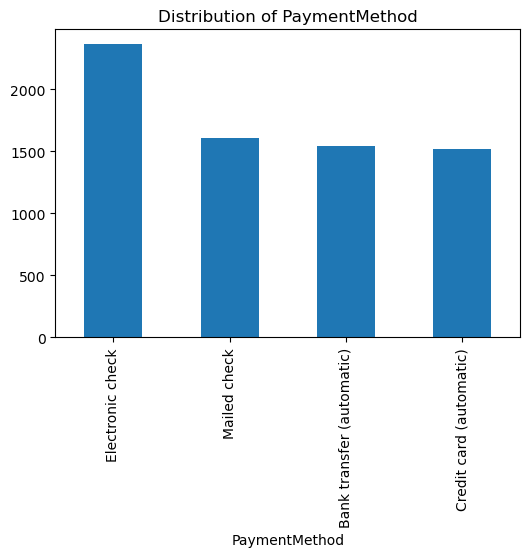

In [42]:
for col in cat_col:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")


- We have roughly equal number of male and female customers<br><br>
- Majority of our customers are not senior citizens<br><br>
- Roughly equal amount of customers that do and do not have a partner<br><br>
- Majority of customers do not have dependents<br><br>
- Most of the customers do have phone service<br><br>
- More customers do not have multiple lines, but many customers do have multiple lines, very few have No phone service which was confirmed by our previous graph.<br><br>
- Most of the customers have fiber optic internet, which is interesting because our previous graph showed that those who have fiber optic internet have a higher churn rate than those who have DSL or no Internet service, so there could be dissatisfaction with the service<br><br>
- Most of the customer also do not have online security<br><br>
- This looks similar to our online security, with more customers choosing to opt our of online backups. <br><br>
- We see similar distributions in internet services and their add ons, online security, online backups, device protection and tech support. This could be because those who pay for fiber optics service already pay more, so those who have it choose to opt out of these services<br><br>
- The distributions of Tv streaming and movies is identical, which makes sense those customers who do not generally watch tv tend to not stream movies either<br><br>
- For contract most are on a month to month, but we have seen that getting them to a yearly or bi yearly contract will decrease their percentage of churning<br><br>
- Most opt in to paperless billing, this also does make sense since most customer are not senior citizens and are more comfortable with technology<br><br>
- We have more people choosing to pay with e-check, which is a problem since most of those customers do tend to churn, the process to pay by e-check might be an issue, so we can encourage them to pay in a different method.<br><br>

## Prepping data for Logistic Regression

### Train test split

In [43]:
X = df[X]
y = df[y].astype(int)

In [44]:
X[:5]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [45]:
y[:5]

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                   random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(4930, 19) (2113, 19)


### Creating Pipeline

In [47]:
process = ColumnTransformer(transformers=[
    ("num", 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown="ignore", drop="first"), cat_col)
])

In [48]:
pipeline = Pipeline(steps=[('process', process), ('model', LogisticRegression(max_iter=3000))])

pipeline.fit(X_train, y_train)

,steps,"[('process', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Model Performance

In [49]:
y_prob = pipeline.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.5).astype(int)

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.808329389493611


- We have an accuracy of approximately 81%, and we did stratify our y in order to maintain the same proportion of classes in the dataset since our dataset did have an imbalance of customers who did not churn

In [51]:
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Confusion Matrix: 
 [[1393  159]
 [ 246  315]]


- We have good performance, but our imbalances of classes does affect performance. The model is better at identifying those who do not churn vs those who do churn since we had a higher rate of false negatives than false positives

In [52]:
print("Report:, \n", classification_report(y_test, y_pred))

Report:, 
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1552
           1       0.66      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



- For class 0 our model predicts the customer did not churn with an accuracy of 85%, The model correctly identifies 90% of the customers who did not churn <br><br>
for class 0 our model predicts the customer will churn and is correct 67% of the time, the model only catches 56% of those who actually churn. We are not detecting customers who churn effectively, which is a problem due to our imbalanced dataset.

### ROC Curve

In [53]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

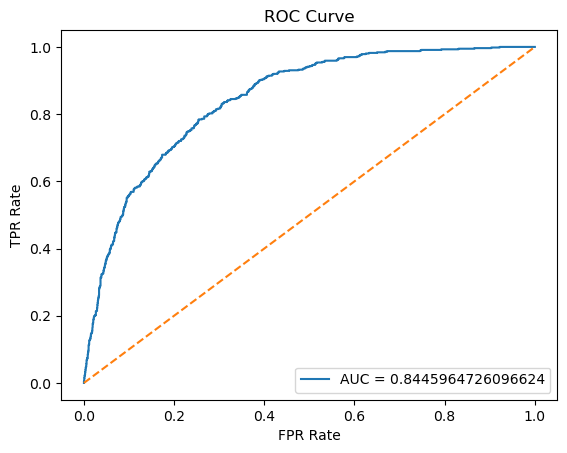

In [54]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("FPR Rate")
plt.ylabel("TPR Rate")
plt.title("ROC Curve")
plt.legend()

- Here our model is better than just flipping a coin to determine whether a customer will churn.<br><br>
- At a low false positive rate our model achieves a fairly high true positive rate which means we can correctly identify those who churn without flagging those who have been loyal to the company.<br><br>

- We achieve a AUC of 0.84 which indicates we have a solid model, we have a high accuracy for those who did not churn, but miss many of those who will churn. We could decrease our threshhold which would increase our TPR in order to account for his, but we would end up flagging more customers who are loyal and will not churn. <br><br>

- In this case decreasing our threshold might not be a bad idea since the worst case scenario we flag a customer that will most likely not churn, this might be giving them a call or sending them promotions, but we catch those customers who will churn

# KNN

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [56]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


## Pipeline for KNN

In [57]:
process_knn = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop='first'), cat_col)
])

- Here we are going to scale our data since kNN uses distances, and we want to keep the distance of our data points as close as possible since we are not learning any parameters just using their distances to calculate the group they belong to

In [58]:
knn_pipe = Pipeline([
    ('process_knn', process_knn),
    ('model', KNeighborsClassifier())
])

In [59]:
knn_pipe.fit(X_train, y_train)

,steps,"[('process_knn', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


- We kept the default parameters for our kNN model as it computes the Euclidean distance with p being equal to 2

## Cross Validation

In [60]:
scores = cross_val_score(knn_pipe, X_train, y_train, cv=5)
scores

array([0.76267748, 0.77586207, 0.78296146, 0.77484787, 0.7464503 ])

In [61]:
scores.mean()

0.7685598377281947

In [62]:
y.value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

- Here we get a score of roughly 76% but given our high class imbalance of about 73% of customers who did not churn as a baseline the knn model showed limited improvement if we just guessed customers not churning for the entire dataset. Barley losing to our model by roughly 3%. Based on cross validation on how well our model will perform on unseen data.

## Confusion Matrix

In [63]:
knn_preds = knn_pipe.predict(X_test)
knn_preds

array([1, 0, 1, ..., 0, 1, 0])

In [64]:
confusion_matrix(y_test , knn_preds)

array([[1316,  236],
       [ 256,  305]], dtype=int64)

## Classification Report

In [65]:
print(classification_report(y_test, knn_preds))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1552
           1       0.56      0.54      0.55       561

    accuracy                           0.77      2113
   macro avg       0.70      0.70      0.70      2113
weighted avg       0.76      0.77      0.77      2113



- Our model does fairly well with an accuracy of 84% identifying customers who will or will not churn. (**precision**). It also did well classifying those actually churned, our true positive rate (**recall**). Where we have a problem is predicting the customers who did churn. We achieved an accuracy score of 56% identifying those customers. We only caught 54% of those customers who actually churned meaning we missed almost half (**recall**). Our model missed a lot of customers who churned this is due to the high class imbalance. So our model for this case isn't that great we want to make sure we we catch those who actually churn because this is money lost for the company. 

## ROC_AUC

In [66]:
from sklearn.metrics import roc_auc_score

In [67]:
knn_prob = knn_pipe.predict_proba(X_test)[:,1]
roc_auc_score(y_test, knn_prob)

0.7882497656982193

- Our model got an AUC score of roughly 78% 

## Assumptions

- kNN assumes that similar data points are close together, so for this example those who churn and near each other on a graph and those who do not churn are near each other as well, this isn't always the case<br><br>
- The distance the points are from each other is meaningful because this means that closer the data points are then the more similar they are as well<br><br>
- kNN also assumes that each feature contributes and equal amount after we scale which we did for this case. <br><br>

## Limitations

- Features must be scaled since we are computing the distances between points<br><br>
- kNN is also sensitive to irrelevant features <br><br>
- It is more computationally heavy than most algorithms since we are computing distances in this case euclidean distances<br><br>
- kNN also does not do well with high dimensional data<br><br>
- It also struggles with imbalanced data, for example our dataset had a limited number of customers who churned, if you imagine this on a graph we have much more data points of customers who did not churn than those who did churn. Since kNN uses these points in order to determine what group new data points belong to, by counting the groups nearest to the new data point to determine the group of the new data point, you can imagine having less of one class will cause a bias in our model leaning towards the class with the most data points. 

## Comparing kNN and Logistic Regression

- Both of the models were evaluated with identical pipelines and 5 fold cross validation. All performance methods we analyzed (precision, recall, f1, and ROC scores)

In [68]:
log_val = cross_val_score(pipeline, X_train, y_train, cv=5)

In [69]:
print(f"Log Validation scores: {log_val.mean()}")
print(f"kNN Validation scores: {scores.mean()}")

Log Validation scores: 0.8032454361054766
kNN Validation scores: 0.7685598377281947


- Our Logistic Regression model outperforms our kNN model  in generalization. Overall the model performs better. This could be because we have high dimensionality in our dataset. We could condense the features down to only those with the highest predictive power and it can improve our kNN model.

# Reference

Zhang, Z. (2016). Introduction to machine learning: k-nearest neighbors. Annals of Translational Medicine, 4(11), 218. https://pmc.ncbi.nlm.nih.gov/articles/PMC4916348/
<br><br>
GeeksforGeeks. (2026, January 13). k-nearest neighbor algorithm using Sklearn – Python. https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbor-algorithm-in-python/

# Decision Tree and Random Forest

## Decision Tree

In [70]:
from sklearn.tree import DecisionTreeClassifier

### Pipeline

In [71]:
process_tree = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_col)
])

In [72]:
decision_tree_pipe = Pipeline([
    ('process_tree', process_tree),
    ('model', DecisionTreeClassifier())
])

In [73]:
decision_tree_pipe.fit(X_train, y_train)

,steps,"[('process_tree', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Accuracy

In [74]:
tree_train_acc = decision_tree_pipe.score(X_train, y_train)
tree_test_acc = decision_tree_pipe.score(X_test, y_test)

print(f"Train Accuracy Tree: {tree_train_acc} \nTest Accuracy Tree: {tree_test_acc}")

Train Accuracy Tree: 0.9275862068965517 
Test Accuracy Tree: 0.7193563653573118


- Here we can see we have an overfitting issue because we achieve very high accuracy on the training set, but low accuracy on our test set, this is expected because we did not assign a max depth in our tree

### Visualizing Tree

In [75]:
from sklearn.tree import export_graphviz
import graphviz

In [76]:
tree = decision_tree_pipe.named_steps["model"]
features = decision_tree_pipe.named_steps['process_tree'].get_feature_names_out()

In [77]:
dot_data = export_graphviz(
    tree,
    feature_names=features,
    class_names=[str(c) for c in tree.classes_],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph

In [78]:
graph.render('tree', format='png', cleanup=True)

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.298221 to fit


'tree.png'

- Our tree has too much depth it is hard to render and is messy to say the least even exported to a png, so we need to do something about this.

### Tuning

In [79]:
process_tree_v2 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown="ignore", drop='first'), cat_col)
])

In [80]:
decision_tree_pipe_v2 = Pipeline([
    ('process_tree_v2', process_tree_v2),
    ('model_v2', DecisionTreeClassifier(criterion='gini', max_depth=7))
])

In [81]:
decision_tree_pipe_v2.fit(X_train, y_train)

,steps,"[('process_tree_v2', ...), ('model_v2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
tree_train_acc_v2 = decision_tree_pipe_v2.score(X_train, y_train)
tree_test_acc_v2 = decision_tree_pipe_v2.score(X_test, y_test)

print(f"Train Accuracy: {tree_train_acc_v2}\nTest Accuracy: {tree_test_acc_v2}")

Train Accuracy: 0.7953346855983773
Test Accuracy: 0.7624230951254141


- After testing a few depths a max depth of 7 achieved reasonable train and testing accuracy, adding more depth to the tree creates too much variance and complexity

In [83]:
tree = decision_tree_pipe_v2.named_steps["model_v2"]
features = decision_tree_pipe_v2.named_steps['process_tree_v2'].get_feature_names_out()

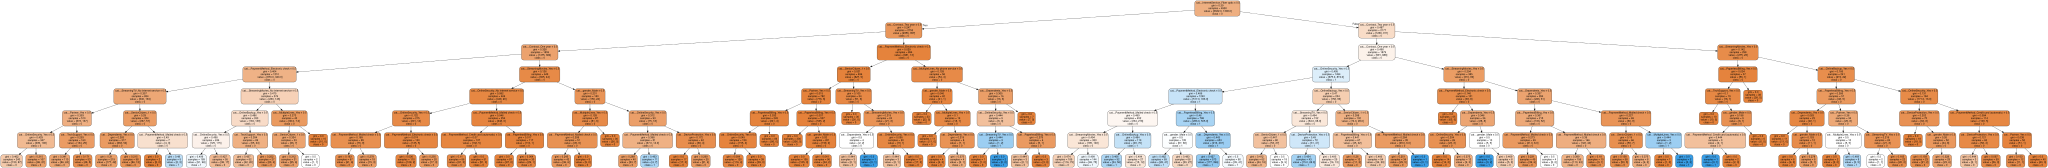

In [84]:
dot_data = export_graphviz(
    tree,
    feature_names=features,
    class_names=[str(c) for c in tree.classes_],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph

In [85]:
graph.render('tree_v2', format='png', cleanup=True)

'tree_v2.png'

- It is interesting to see that our root node is fiber optic internet. This confirms our analysis earlier about internet service type. Where we had more customers churn who had fiber optic internet than those with different services. 
<br><br>
- From here we now know that fiber optic customers behave differently from non fiber customers. This is something that our logistic regression model did not capture. We do not have one single relationship for all customers, but instead we now know that we have different groups of customers that behave differently.
<br><br>
- Although accuracy is slightly less for this model, I believe removing some features or aggregating them into a single column would improve our performance. The model also struggles because we have a high class imbalance and trees tend to favor those classes

### Metrics

In [86]:
y_pred_tree = decision_tree_pipe_v2.predict(X_test)
y_prob_tree = decision_tree_pipe_v2.predict_proba(X_test)[:,1]

In [87]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1552
           1       0.56      0.52      0.54       561

    accuracy                           0.76      2113
   macro avg       0.69      0.69      0.69      2113
weighted avg       0.76      0.76      0.76      2113



- We achieve similar scores to our logistic regression and knn model, this is the bias our model in capturing due to the high class imbalance that is present in our dataset. <br><br>
- We are still having trouble identifying those who will actually churn, the high class imbalance is still hurting our model performance

### ROC_AUC

In [88]:
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)
print(roc_auc_tree)

0.7949658424756969


In [89]:
fpr, tpr, _  = roc_curve(y_test, y_prob_tree)

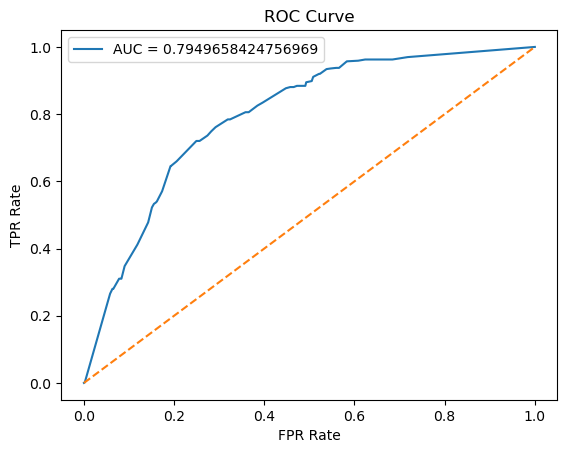

In [90]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_tree:}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("FPR Rate")
plt.ylabel("TPR Rate")
plt.title("ROC Curve")
plt.legend()

- We achieve a AUC of 0.79 which is fair, but still falls short of our logistic regression model we do a decent job indentifying customer who will not churn but still struggle with those who will churn

## Random Forest

In [91]:
from sklearn.ensemble import RandomForestClassifier

### Pipeline

In [92]:
rf_pipeline = Pipeline([
    ("process", process),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=7, 
        
    ))
])

In [93]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('process', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Accuracy

In [94]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:,1]

In [95]:
print("Accuracy train: ", rf_pipeline.score(X_train, y_train))
print("Accuracy test: ", rf_pipeline.score(X_test, y_test))

Accuracy train:  0.8223123732251522
Accuracy test:  0.7979176526265973


- We achieve very higher test accuracy than regular decision trees using the same depth, our test accuracy is also similar to our training set. So we achieve good generalization.

### Metrics

In [96]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1552
           1       0.67      0.47      0.55       561

    accuracy                           0.80      2113
   macro avg       0.75      0.69      0.71      2113
weighted avg       0.79      0.80      0.79      2113



- We achieve very high recall with this model for customers who do not churn. We are seeing similar metrics across the board for all models, indicating that this class imbalance might be the root cause of our performance. This model performs worse identifying the customers who actually churn.

### ROC_AUC

In [97]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

In [98]:
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

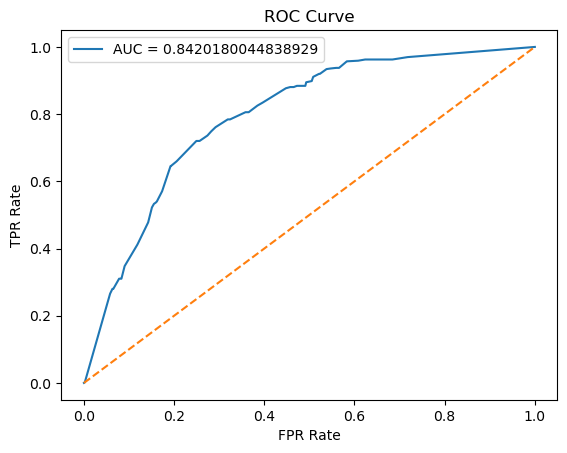

In [99]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_rf:}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("FPR Rate")
plt.ylabel("TPR Rate")
plt.title("ROC Curve")
plt.legend()

- We improved upon our decision tree model. We achieve a reasonable score of 0.84 which is similar to our logistic regression model. 

### Feature Importance

In [100]:
rf_model = rf_pipeline.named_steps["model"]
feature_names = rf_pipeline.named_steps["process"].get_feature_names_out()

importances = rf_model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values(by="Importance", ascending=False)
)

In [101]:
importance_df

,Feature,Importance
0,num__tenure,0.216469
2,num__TotalCharges,0.134563
10,cat__InternetService_Fiber optic,0.092808
1,num__MonthlyCharges,0.084873
25,cat__Contract_Two year,0.078663
28,cat__PaymentMethod_Electronic check,0.077467
24,cat__Contract_One year,0.036603
19,cat__TechSupport_Yes,0.027454
13,cat__OnlineSecurity_Yes,0.027424
26,cat__PaperlessBilling_Yes,0.021949


- Our most important feature tenure meaning the length of the customer staying with the company strongly determines their behavior. New customers tend to behave differently than tenured customers. <br><br>
- Total charges comes second meaning that long financial payments matter more than single monthly payments

## Summary

- Overall our Logistic Regression Model and our Random Forest models performed similarly. The question is which model should we choose in this case?  <br><br>
- Initially I would go with the Logistic Regression model due to its simplicity and interpretability, but one thing our decision tree models suggested is that our data is not linear and behaves non linearly. This is because we have different subgroups in our data and each group behaves differently. Logistic Regression assumes that an increase in monthly payments will bring up churn rate equally for all customers, since we have one global function modeling the data. This is not the case. Our trees showed us that depending on the type of customer the features do not affect everyone equally. An increase in monthly payments will not increase churn rate equally for long  tenured customers and new customers. For this instance I would go with our random forest model because it forms to our data better than the logistic regression model.  <br><br>
- This is interesting because this means we can analyze these different groups independently and determine why these groups churn or not. This will be more of an analysis task to gain more information about the customers. I also wonder if using unsupervised algorithms would lead us to the same conclusion.